# Quantum Chemistry: Toy H2 Hamiltonian Solver

This notebook uses a standard small qubit Hamiltonian model for molecular hydrogen after symmetry reduction. It computes the ground energy and demonstrates low-energy filtering on the chemistry Hamiltonian.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.design import design_projector_polynomial
from qsvt.hamiltonians import pauli_string_matrix
from qsvt.polynomials import eval_polynomial
from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian

# Common two-qubit H2 example coefficients near the equilibrium geometry.
c0 = -1.052373245772859
c1 = 0.39793742484318045
c2 = -0.39793742484318045
c3 = -0.01128010425623538
c4 = 0.18093119978423156

H = (
    c0 * pauli_string_matrix("II")
    + c1 * pauli_string_matrix("ZI")
    + c2 * pauli_string_matrix("IZ")
    + c3 * pauli_string_matrix("ZZ")
    + c4 * pauli_string_matrix("XX")
)
energies, vecs = eigh_hermitian(H)
ground_energy = energies[0]
ground_energy

np.float64(-1.85727503020238)

In [2]:
cutoff = 0.5 * (energies[0] + energies[1])
scale = np.max(np.abs(cutoff - energies))
A = (cutoff * np.eye(H.shape[0]) - H) / scale

coeffs = design_projector_polynomial(gamma=0.15, degree=17)
P_ground = apply_polynomial_to_hermitian(A, coeffs)

trial = np.array([1.0, 0.0, 0.0, 0.25])
trial = trial / np.linalg.norm(trial)
filtered = P_ground @ trial
filtered = filtered / np.linalg.norm(filtered)

ground_vec = vecs[:, 0]
initial_overlap = abs(np.vdot(ground_vec, trial)) ** 2
filtered_overlap = abs(np.vdot(ground_vec, filtered)) ** 2
energy_estimate = np.real(np.vdot(filtered, H @ filtered))

initial_overlap, filtered_overlap, energy_estimate

(np.float64(3.4911941432755493e-35),
 np.float64(6.719832005838039e-33),
 np.float64(-0.9424088608987823))

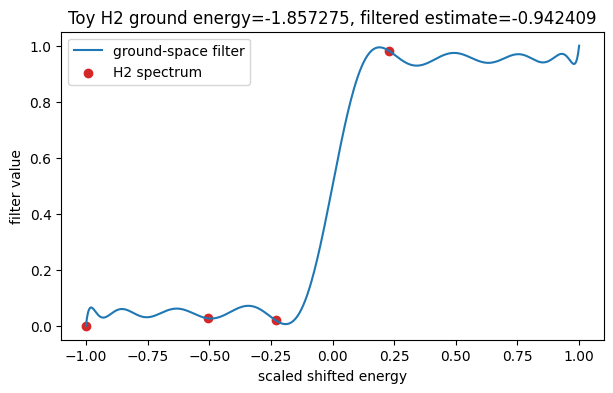

In [3]:
xs = np.linspace(-1, 1, 500)
plt.figure(figsize=(7, 4))
plt.plot(xs, eval_polynomial(coeffs, xs), label="ground-space filter")
plt.scatter(
    np.linalg.eigvalsh(A),
    eval_polynomial(coeffs, np.linalg.eigvalsh(A)),
    color="tab:red",
    label="H2 spectrum",
)
plt.xlabel("scaled shifted energy")
plt.ylabel("filter value")
plt.title(
    f"Toy H2 ground energy={ground_energy:.6f}, filtered estimate={energy_estimate:.6f}"
)
plt.legend()
plt.show()